Bivariate Analysis
this is the fun part! 

instead of looking at variables in isolation, we are now going to cross-reference them. specifically we want to know **how each feature relates to our target outcome (`won`)**

In [77]:
import matplotlib.pyplot as plt
import pandas as pd 
stories = pd.read_excel('../data/stories_cleaned.xlsx')
heroines = pd.read_excel('../data/candidates_cleaned.xlsx')
df = pd.merge(heroines, stories, on="story_id")

### THE FIRST GIRL RULE 
The first girl introduced to the audience is usually the girl who is destined to win and we want to calculate the win-rate percentage of first girls and not the first girl


we want to answer the ***BIG QUESTION*** does entering the story first actually give a heroine a statistically significant advantage

Text(0.5, 1.0, 'Winrate')

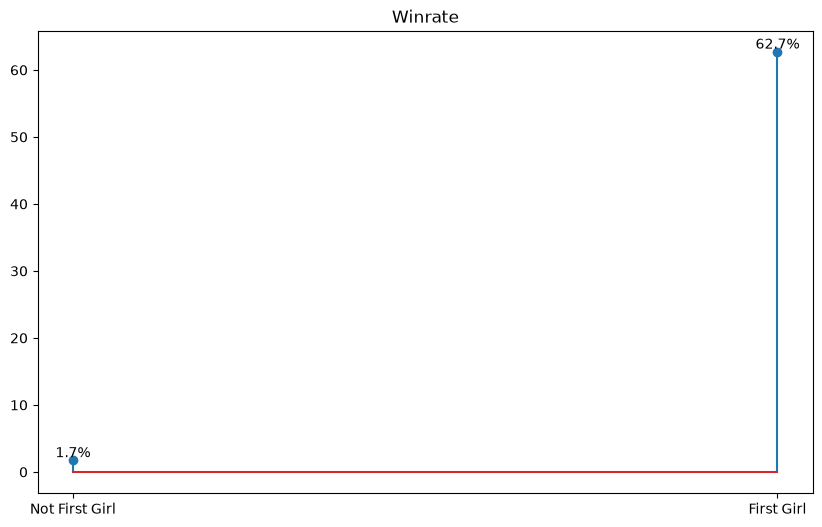

In [78]:

first_girl = (df["first_girl"] == 1).sum()
notFirst_girl =(df["first_girl"] == 0 ).sum()

winrate = df.groupby("first_girl")["won"].mean() * 100
winrate.index = ["Not First Girl", "First Girl"]


plt.figure(figsize=(10,6))

plt.stem(winrate.index, winrate.values)

for x, y in zip(winrate.index, winrate.values):
    plt.text(x, y, f"{y:.1f}%", ha="center", va="bottom")

plt.title("Winrate")

# I DONT WANT TO BAR GRAPH NO MORE

Childhood friend vs winner


                      count  sum      mean   win_rate
childhood_connection                                 
Acquaintance              3    1  0.333333  33.333333
Childhood Friend         29    2  0.068966   6.896552
Childhood Promise        16    7  0.437500  43.750000


Text(0.5, 1.0, 'Win rate by connection')

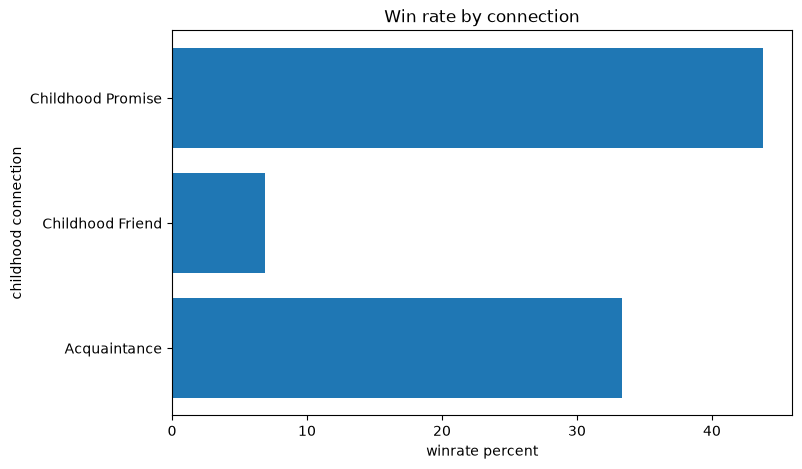

In [79]:
childhood_analysis = df.groupby("childhood_connection")["won"].agg(
    ["count", "sum", "mean"*1]
)

childhood_analysis["win_rate"] = childhood_analysis["mean"] * 100

print(childhood_analysis)
plt.figure(figsize=(8,5))

plt.barh(childhood_analysis.index, childhood_analysis["win_rate"])

plt.xlabel("winrate percent")
plt.ylabel("childhood connection")
plt.title("Win rate by connection")



dere type

                   count  wins   win_rate
primary_archetype                        
Dandere               59     7  11.864407
Deredere              45     8  17.777778
Genki                 57     2   3.508772
Kuudere               41    11  26.829268
Onee-san              23     1   4.347826
Tsundere              73    17  23.287671
Yandere                3     0   0.000000


Text(0, 0.5, 'dere type')

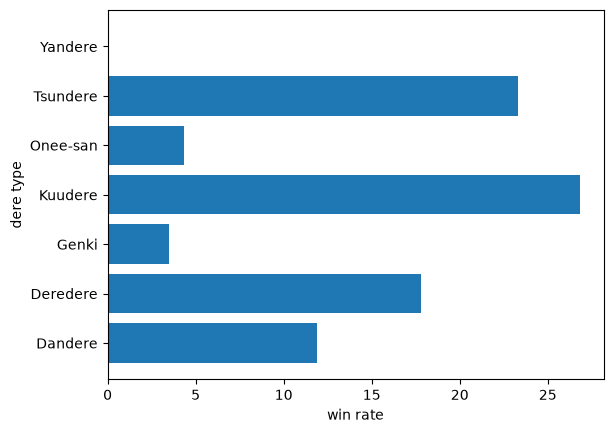

In [80]:
dere_analysis= df.groupby("primary_archetype")["won"].agg(
    count ="count",
    wins="sum",
    win_rate= "mean"

)
dere_analysis["win_rate"] = dere_analysis["win_rate"] * 100
print(dere_analysis)

plt.barh(dere_analysis.index, dere_analysis.win_rate)
plt.xlabel("win rate")
plt.ylabel("dere type")

haircolor

            count  wins   win_rate
hair_color                        
Black          81    19  23.456790
Blonde         38     5  13.157895
Blue           26     2   7.692308
Brown          83    12  14.457831
Green           3     0   0.000000
Orange          9     2  22.222222
Pink           13     1   7.692308
Purple         15     2  13.333333
Red            12     2  16.666667
Silver         19     1   5.263158
White           2     0   0.000000


Text(0.5, 1.0, 'hair color analysis')

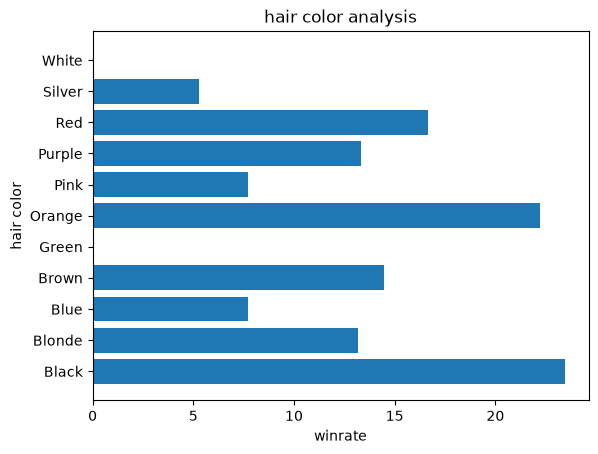

In [81]:
from matplotlib.pyplot import barh
haircolor_analysis = df.groupby("hair_color")["won"].agg(
    count = "count",
    wins = "sum",
    win_rate = "mean"

)

haircolor_analysis["win_rate"] = haircolor_analysis["win_rate"] * 100
print(haircolor_analysis)

plt.barh(
    haircolor_analysis.index,
    haircolor_analysis["win_rate"]
)

plt.xlabel("winrate")
plt.ylabel("hair color")
plt.title("hair color analysis")